In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

import matplotlib.pyplot as plt

# Make plots show inside the notebook
%matplotlib inline

# Load your dataset (CSV must be in the same folder as this notebook)
df = pd.read_csv("printable.csv")

# Look at the first few rows
df.head()


,design_id,gd_safety_factor,gd_min_thickness_mm,max_overhang_angle,gd_unrestricted_flag,max_von_mises_mpa,mass_kg,volume_mm3,support_mass_g,support_volume_ml,estimated_print_time_min,material_used_g,slenderness_ratio,small_base_flag,thin_neck_flag,complexity_flag,print_success
0,Baseline_1,1.5,3.0,45,0,15.0,0.065,61680,0.88,0.29,60,28.10,2.497500,0.0,0.5,0.5,1.00
1,GD_Realistic_1,1.5,3.0,45,0,13.3,0.038,36157,2.89,0.95,69,21.21,2.628947,0.2,1.0,0.5,0.90
2,GD_Realistic_2,1.5,3.0,45,0,13.3,0.035,32984,1.69,0.56,56,18.76,2.700000,0.2,0.8,0.6,0.90
3,GD_Unrestricted_1_1,1.5,3.0,45,1,13.3,0.036,33593,3.07,1.01,63,20.35,2.912056,0.2,0.9,0.6,0.85
4,GD_Unrestricted_1_2,1.5,3.0,45,1,13.3,0.038,36157,2.89,0.95,69,21.21,2.856857,0.2,0.8,0.7,0.85


In [5]:
# Only drop the ID column (it's not a useful feature for ML)
df_clean = df.drop(columns=["design_id"])

# Check columns
df_clean.head()


,gd_safety_factor,gd_min_thickness_mm,max_overhang_angle,gd_unrestricted_flag,max_von_mises_mpa,mass_kg,volume_mm3,support_mass_g,support_volume_ml,estimated_print_time_min,material_used_g,slenderness_ratio,small_base_flag,thin_neck_flag,complexity_flag,print_success
0,1.5,3.0,45,0,15.0,0.065,61680,0.88,0.29,60,28.10,2.497500,0.0,0.5,0.5,1.00
1,1.5,3.0,45,0,13.3,0.038,36157,2.89,0.95,69,21.21,2.628947,0.2,1.0,0.5,0.90
2,1.5,3.0,45,0,13.3,0.035,32984,1.69,0.56,56,18.76,2.700000,0.2,0.8,0.6,0.90
3,1.5,3.0,45,1,13.3,0.036,33593,3.07,1.01,63,20.35,2.912056,0.2,0.9,0.6,0.85
4,1.5,3.0,45,1,13.3,0.038,36157,2.89,0.95,69,21.21,2.856857,0.2,0.8,0.7,0.85


In [6]:
# Target we want to predict
y = df_clean["print_success"]

# Features: everything except the target
X = df_clean.drop(columns=["print_success"])

X.shape, y.shape


((20, 15), (20,))

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # 30% test
    random_state=42
)

X_train.shape, X_test.shape


((14, 15), (6, 15))

In [8]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R^2 score: {r2:.3f}")
print(f"Mean Absolute Error: {mae:.3f}")


R^2 score: 0.852
Mean Absolute Error: 0.095


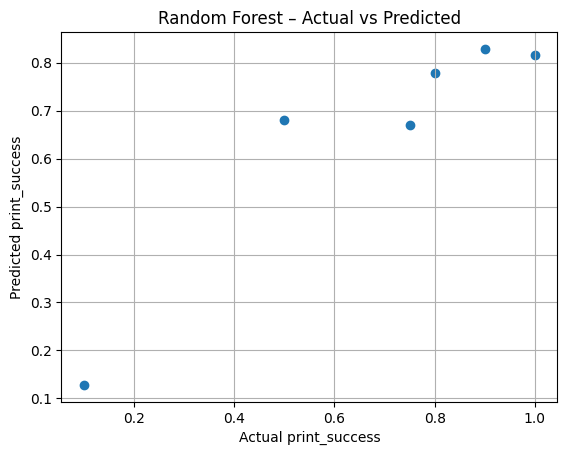

In [10]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual print_success")
plt.ylabel("Predicted print_success")
plt.title("Random Forest – Actual vs Predicted")
plt.grid(True)
plt.show()


In [11]:
# Feature Importance
import pandas as pd
import numpy as np

importances = rf.feature_importances_
feature_names = X.columns

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

fi_df


,feature,importance
12,small_base_flag,0.220573
11,slenderness_ratio,0.182158
4,max_von_mises_mpa,0.145707
10,material_used_g,0.074443
6,volume_mm3,0.074107
5,mass_kg,0.073570
13,thin_neck_flag,0.072358
14,complexity_flag,0.050849
2,max_overhang_angle,0.036145
7,support_mass_g,0.026614


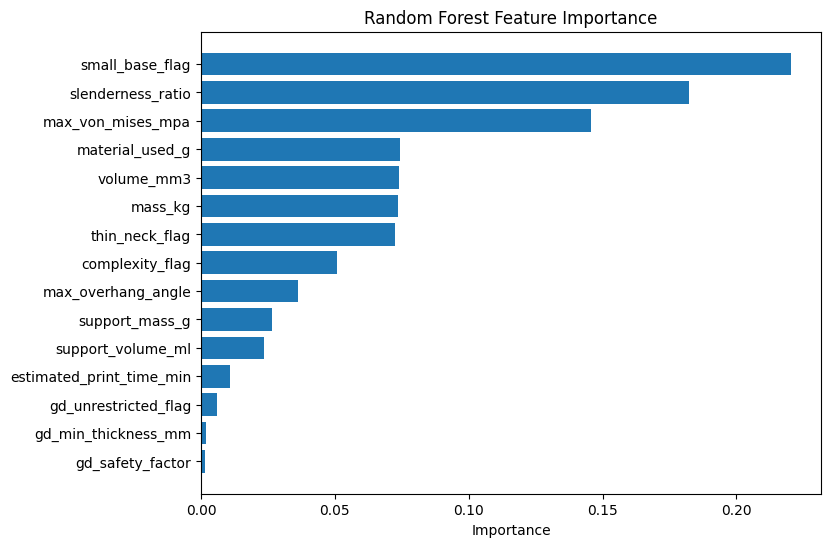

In [12]:
plt.figure(figsize=(8,6))
plt.barh(fi_df["feature"], fi_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()
